In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../data/raw/dataset_revision.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10043 entries, 0 to 10042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        10043 non-null  object 
 1   gender            10043 non-null  object 
 2   SeniorCitizen     10043 non-null  int64  
 3   Partner           10043 non-null  object 
 4   Dependents        10043 non-null  object 
 5   tenure            10043 non-null  int64  
 6   PhoneService      10043 non-null  object 
 7   MultipleLines     10043 non-null  object 
 8   InternetService   10043 non-null  object 
 9   OnlineSecurity    10043 non-null  object 
 10  OnlineBackup      10043 non-null  object 
 11  DeviceProtection  10043 non-null  object 
 12  TechSupport       10043 non-null  object 
 13  StreamingTV       10043 non-null  object 
 14  StreamingMovies   10043 non-null  object 
 15  Contract          10043 non-null  object 
 16  PaperlessBilling  10043 non-null  object

In [4]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10038,sdv-id-Fmtawh,Female,1,No,No,26,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,85.98,421.59,No
10039,sdv-id-rxOgFc,Female,0,No,No,61,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,83.67,1076.77,No
10040,sdv-id-jBlECX,Male,1,No,Yes,61,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),25.32,808.03,No
10041,sdv-id-qROYcp,Female,0,No,No,60,Yes,Yes,DSL,No,...,No,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),88.58,6151.07,No


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,10043.000000,10043.000000,10043.000000,10043.000000
mean,0.142886,33.542169,65.214834,2407.121986
std,0.349974,25.210377,31.086593,2410.734297
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,8.000000,33.435000,355.550000
50%,0.000000,32.000000,70.850000,1396.250000
75%,0.000000,58.000000,90.800000,4112.225000
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
# cambiar nombre a columna tenure
df.rename(columns={'tenure': 'Antiguedad'}, inplace=True)

In [7]:
#Quitamos los 0 en antiguedad multiplicando monthly y antguedad, quedaran a 0 los que tambine llevan 0 meses
mask = df['TotalCharges'] == 0
df.loc[mask, 'TotalCharges'] = (df['MonthlyCharges'] * df['Antiguedad'])

In [8]:
#Quitamos los 0 en antiguedad y lo dividimos por los cargos mensuales
mask = df['Antiguedad'] == 0
df.loc[mask, 'Antiguedad'] = (df['TotalCharges'] / df['MonthlyCharges']).astype(int)

In [9]:
df.Antiguedad.describe()

count    10043.000000
mean        33.601215
std         25.169079
min          0.000000
25%          8.000000
50%         32.000000
75%         58.000000
max         86.000000
Name: Antiguedad, dtype: float64

In [10]:
df.MonthlyCharges.describe()

count    10043.000000
mean        65.214834
std         31.086593
min         18.250000
25%         33.435000
50%         70.850000
75%         90.800000
max        118.750000
Name: MonthlyCharges, dtype: float64

In [11]:
#CALCULO TASA DE ABANDONO
churn_counts = df['Churn'].value_counts()
churn_rate = (churn_counts['Yes'] / len(df)) * 100
print(f"Tasa de Churn Global: {churn_rate:.2f}%")

Tasa de Churn Global: 26.32%


In [12]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

Churn
No     7400
Yes    2643
Name: count, dtype: int64
Churn
No     0.736832
Yes    0.263168
Name: proportion, dtype: float64


In [13]:
print(df['Antiguedad'].mean())
print(df['MonthlyCharges'].mean())
print(df['TotalCharges'].mean())


33.60121477646122
65.2148342128846
2408.3443801652893


/tmp/ipykernel_13090/24405446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='Churn', palette='Set2')


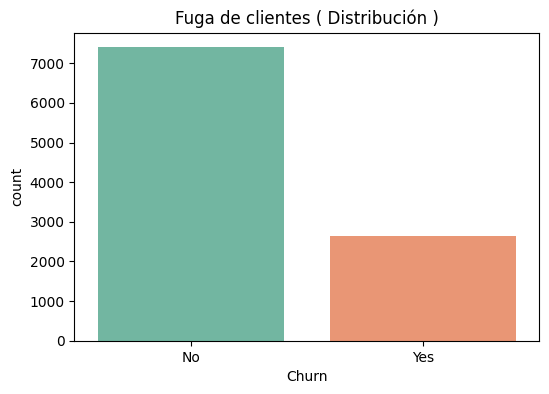

In [14]:
# FUGA DE CLIENTES CHURN RATE
plt.figure(figsize=(6, 4))
sns.countplot(df, x='Churn', palette='Set2')
plt.title('Fuga de clientes ( Distribución )')
plt.show()

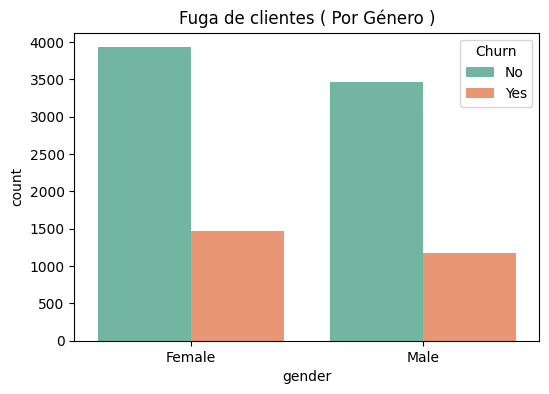

In [15]:
# HOMBRES O MUJERES?
plt.figure(figsize=(6, 4))
sns.countplot(df, x='gender', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por Género )')
plt.show()

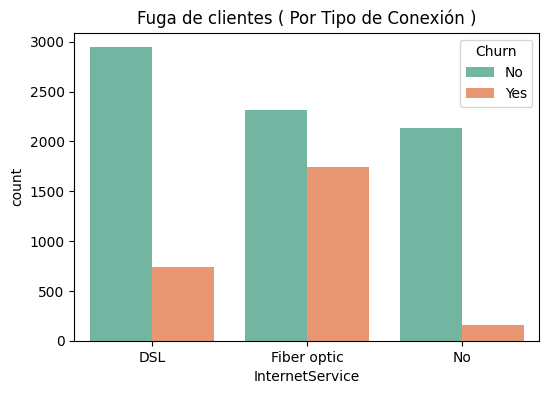

In [16]:
# FUGA POR TIPO DE CONEXION
plt.figure(figsize=(6, 4))
sns.countplot(df, x='InternetService', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por Tipo de Conexión )')
plt.show()

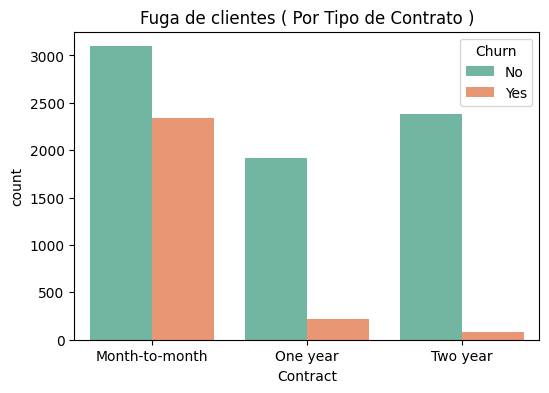

In [17]:
# FUGA POR TIPO DE CONTRATO
plt.figure(figsize=(6, 4))
sns.countplot(df, x='Contract', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por Tipo de Contrato )')
plt.show()

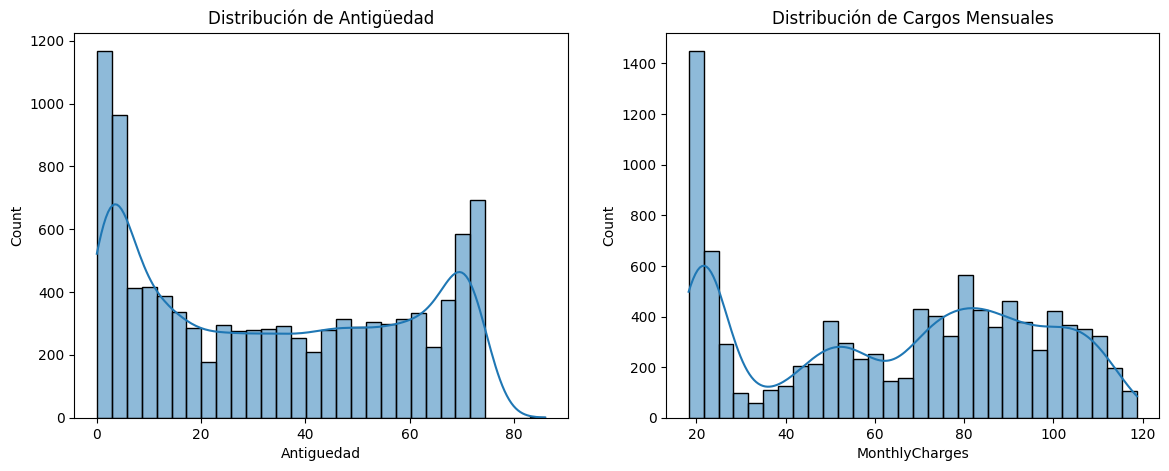

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Antiguedad'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Distribución de Antigüedad')

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=ax[1])
ax[1].set_title('Distribución de Cargos Mensuales')
plt.show()

In [19]:
service_columns = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Función para contar servicios activos
def count_services(row):
    count = 0
    if row['PhoneService'] == 'Yes': count += 1
    if row['MultipleLines'] == 'Yes': count += 1
    if row['InternetService'] in ['DSL', 'Fiber optic']: count += 1
    for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
        if row[col] == 'Yes': count += 1
    return count

# Crear la nueva columna
df['TotalServices'] = df.apply(count_services, axis=1)

In [20]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,Antiguedad,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,4
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10038,sdv-id-Fmtawh,Female,1,No,No,26,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Electronic check,85.98,421.59,No,5
10039,sdv-id-rxOgFc,Female,0,No,No,61,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,83.67,1076.77,No,3
10040,sdv-id-jBlECX,Male,1,No,Yes,61,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),25.32,808.03,No,2
10041,sdv-id-qROYcp,Female,0,No,No,60,Yes,Yes,DSL,No,...,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),88.58,6151.07,No,5


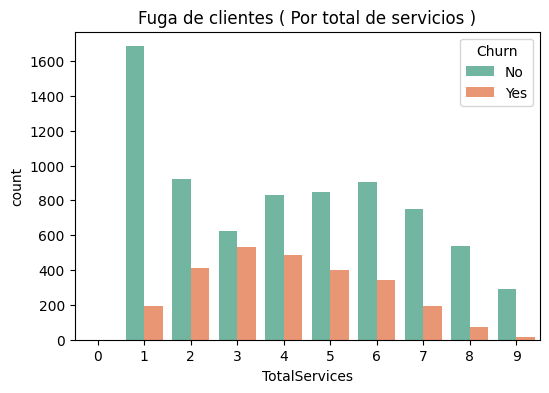

In [21]:
# FUGA POR TIPO DE CONTRATO
plt.figure(figsize=(6, 4))
sns.countplot(df, x='TotalServices', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por total de servicios )')
plt.show()

In [22]:
df['g_antiguedad'] = pd.cut(df['Antiguedad'], 
                     bins=[0, 12, 24, 48, np.inf], 
                     labels=['Hasta 12 meses', '12 a 24', '24 a 48', 'Más de 48'])

In [23]:
# FUGA POR MESES
perlessBilling'

SyntaxError: unterminated string literal (detected at line 2) (2403063275.py, line 2)

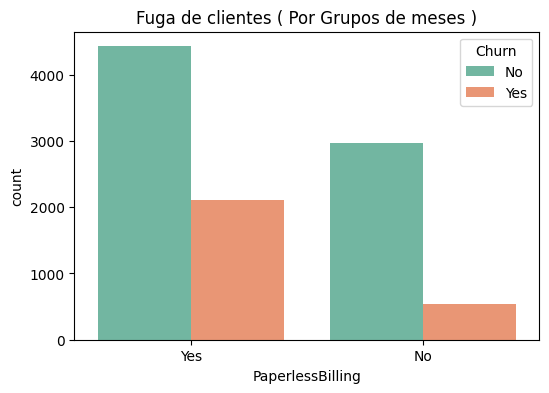

In [ ]:
# FUGA POR PAPERLESS BILLING
plt.figure(figsize=(6, 4))
sns.countplot(df, x='PaperlessBilling', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por Grupos de meses )')
plt.show()

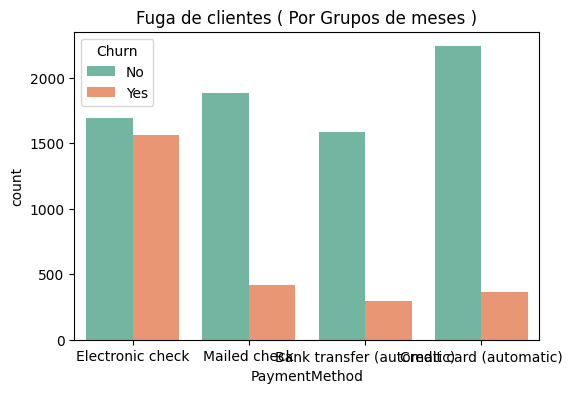

In [ ]:
# FUGA POR PAPERLESS BILLING
plt.figure(figsize=(6, 4))
sns.countplot(df, x='PaymentMethod', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por tipo de pago )')
plt.show()

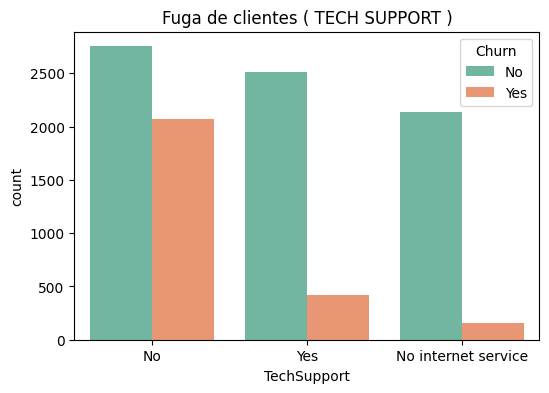

In [ ]:
# FUGA POR TECHSUPPORT
plt.figure(figsize=(6, 4))
sns.countplot(df, x='TechSupport', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( TECH SUPPORT )')
plt.show()

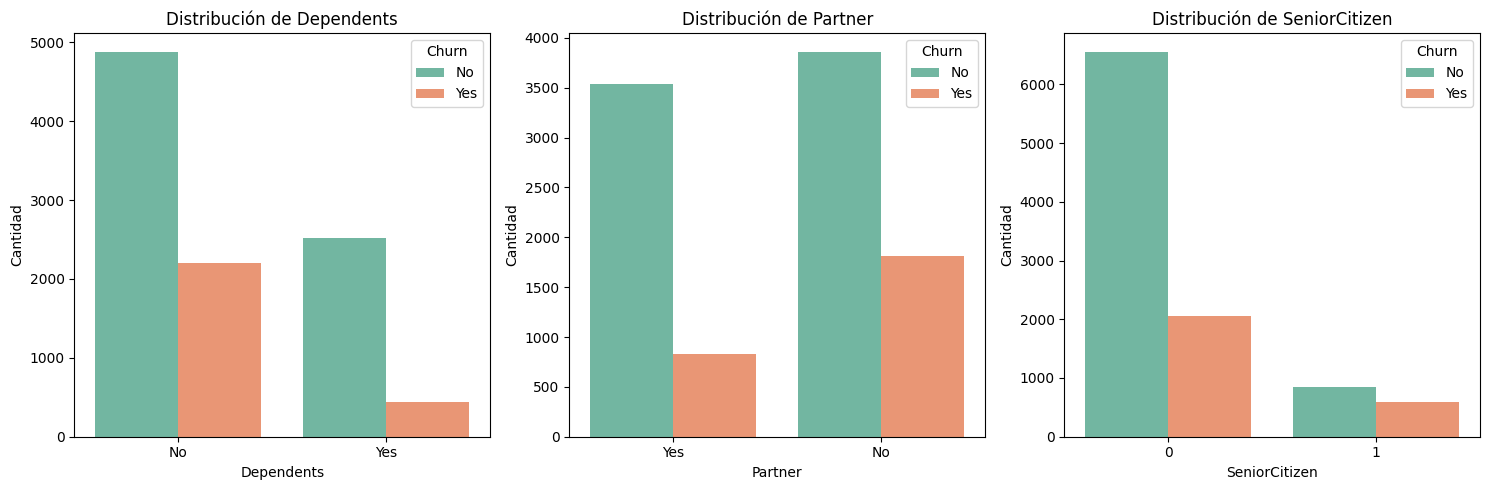

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

columnas = ['Dependents', 'Partner', 'SeniorCitizen']

for i, col in enumerate(columnas):
    sns.countplot(data=df, x=col, hue='Churn', palette='Set2', ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

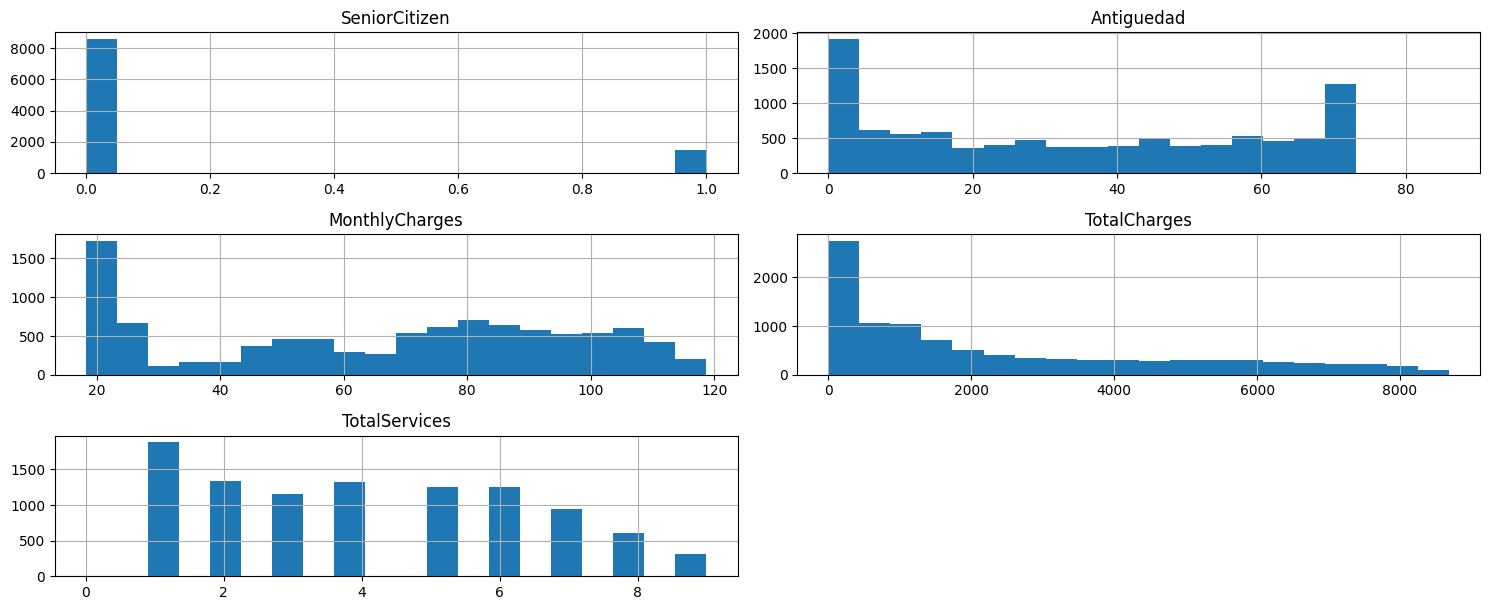

In [ ]:
df.hist(bins=20, figsize=(15, 10), layout=(5, 2))
plt.tight_layout() # Para que no se encabalguen las etiquetas
plt.show()

In [ ]:
df.to_csv('../data/processed/dataset_final_grupos.csv', index=False)

In [ ]:
#eliminamos customerID que no nos dice nada
df = df.drop(columns=['customerID'])
#eliminamos el grupo que no lo vamos a nacesitar
df = df.drop(columns=['g_antiguedad'])
#eliminamos  numero total de servicios, solo se ha creado para ver si cuanto más mejor
df = df.drop(columns=['TotalServices'])


In [ ]:
df.to_csv('../data/processed/dataset_final.csv', index=False)